In [107]:
import pandas as pd
import matplotlib.pyplot as plt
import requests
import os
from dotenv import load_dotenv
import time

In [108]:
load_dotenv()

S2_API_KEY = os.getenv("S2_API_KEY")

In [109]:
arxiv_df = pd.read_csv('data/arxiv_papers.csv')
print(arxiv_df.dtypes)
print(arxiv_df.shape)
arxiv_df

id                  float64
title                   str
first_author            str
authors                 str
published               str
updated                 str
primary_category        str
categories              str
abstract                str
link_url                str
pdf_url                 str
dtype: object
(10000, 11)


,id,title,first_author,authors,published,updated,primary_category,categories,abstract,link_url,pdf_url
0,2505.12581,An approach based on class activation maps for...,Lucas M. Dorneles,"['Lucas M. Dorneles', 'Luan Fonseca Garcia', '...",2025-05-19 00:03:57,2025-05-19 00:03:57+00:00,cs.LG,"['cs.LG', 'cs.AI', 'cs.CV']",Neural networks have become increasingly popul...,http://arxiv.org/abs/2505.12581v1,https://arxiv.org/pdf/2505.12581v1
1,2505.12585,Learning Robust Spectral Dynamics for Temporal...,En Yu,"['En Yu', 'Jie Lu', 'Xiaoyu Yang', 'Guangquan ...",2025-05-19 00:38:18,2025-05-19 00:38:18+00:00,cs.LG,"['cs.LG', 'cs.AI']",Modern machine learning models struggle to mai...,http://arxiv.org/abs/2505.12585v1,https://arxiv.org/pdf/2505.12585v1
2,2505.13544,Multi-head Temporal Latent Attention,Keqi Deng,"['Keqi Deng', 'Philip C. Woodland']",2025-05-19 02:09:41,2025-11-02 20:27:27+00:00,cs.LG,"['cs.LG', 'cs.AI']",While Transformer self-attention offers strong...,http://arxiv.org/abs/2505.13544v3,https://arxiv.org/pdf/2505.13544v3
3,2505.12626,scSiameseClu: A Siamese Clustering Framework f...,Ping Xu,"['Ping Xu', 'Zhiyuan Ning', 'Pengjiang Li', 'W...",2025-05-19 02:17:09,2025-10-02 02:55:07+00:00,q-bio.GN,"['q-bio.GN', 'cs.AI', 'cs.LG']",Single-cell RNA sequencing (scRNA-seq) reveals...,http://arxiv.org/abs/2505.12626v3,https://arxiv.org/pdf/2505.12626v3
4,2505.12632,Scalable Video-to-Dataset Generation for Cross...,Yunseok Jang,"['Yunseok Jang', 'Yeda Song', 'Sungryull Sohn'...",2025-05-19 02:39:03,2025-05-19 02:39:03+00:00,cs.CV,"['cs.CV', 'cs.AI', 'cs.CL', 'cs.LG']",Recent advancements in Large Language Models (...,http://arxiv.org/abs/2505.12632v1,https://arxiv.org/pdf/2505.12632v1
...,...,...,...,...,...,...,...,...,...,...,...
9995,2605.18663,GIM: Evaluating models via tasks that integrat...,Rohit Patel,"['Rohit Patel', 'Alexandre Rezende', 'Steven M...",2026-05-18 17:09:50,2026-05-18 17:09:50+00:00,cs.AI,"['cs.AI', 'cs.CL', 'cs.LG']","As LLM benchmarks saturate, the evaluation com...",http://arxiv.org/abs/2605.18663v1,https://arxiv.org/pdf/2605.18663v1
9996,2605.18732,Predictable Confabulations: Factual Recall by ...,Matthew L. Smith,"['Matthew L. Smith', 'Jonathan P. Shock', 'Sam...",2026-05-18 17:53:44,2026-05-18 17:53:44+00:00,cs.CL,"['cs.CL', 'cs.AI', 'cs.LG']",While scaling laws govern aggregate large lang...,http://arxiv.org/abs/2605.18732v1,https://arxiv.org/pdf/2605.18732v1
9997,2605.18740,Vision-OPD: Learning to See Fine Details for M...,Qianhao Yuan,"['Qianhao Yuan', 'Jie Lou', 'Xing Yu', 'Hongyu...",2026-05-18 17:57:04,2026-05-18 17:57:04+00:00,cs.CV,"['cs.CV', 'cs.AI', 'cs.CL', 'cs.LG']",Multimodal Large Language Models (MLLMs) still...,http://arxiv.org/abs/2605.18740v1,https://arxiv.org/pdf/2605.18740v1
9998,2605.18746,ESI-Bench: Towards Embodied Spatial Intelligen...,Yining Hong,"['Yining Hong', 'Jiageng Liu', 'Han Yin', 'Man...",2026-05-18 17:59:02,2026-05-18 17:59:02+00:00,cs.CV,"['cs.CV', 'cs.AI', 'cs.CL', 'cs.LG', 'cs.RO']",Spatial intelligence unfolds through a percept...,http://arxiv.org/abs/2605.18746v1,https://arxiv.org/pdf/2605.18746v1


In [110]:
arxiv_df['id'] = arxiv_df["id"].apply(lambda x: f"{float(x):.5f}").tolist()
arxiv_df

,id,title,first_author,authors,published,updated,primary_category,categories,abstract,link_url,pdf_url
0,2505.12581,An approach based on class activation maps for...,Lucas M. Dorneles,"['Lucas M. Dorneles', 'Luan Fonseca Garcia', '...",2025-05-19 00:03:57,2025-05-19 00:03:57+00:00,cs.LG,"['cs.LG', 'cs.AI', 'cs.CV']",Neural networks have become increasingly popul...,http://arxiv.org/abs/2505.12581v1,https://arxiv.org/pdf/2505.12581v1
1,2505.12585,Learning Robust Spectral Dynamics for Temporal...,En Yu,"['En Yu', 'Jie Lu', 'Xiaoyu Yang', 'Guangquan ...",2025-05-19 00:38:18,2025-05-19 00:38:18+00:00,cs.LG,"['cs.LG', 'cs.AI']",Modern machine learning models struggle to mai...,http://arxiv.org/abs/2505.12585v1,https://arxiv.org/pdf/2505.12585v1
2,2505.13544,Multi-head Temporal Latent Attention,Keqi Deng,"['Keqi Deng', 'Philip C. Woodland']",2025-05-19 02:09:41,2025-11-02 20:27:27+00:00,cs.LG,"['cs.LG', 'cs.AI']",While Transformer self-attention offers strong...,http://arxiv.org/abs/2505.13544v3,https://arxiv.org/pdf/2505.13544v3
3,2505.12626,scSiameseClu: A Siamese Clustering Framework f...,Ping Xu,"['Ping Xu', 'Zhiyuan Ning', 'Pengjiang Li', 'W...",2025-05-19 02:17:09,2025-10-02 02:55:07+00:00,q-bio.GN,"['q-bio.GN', 'cs.AI', 'cs.LG']",Single-cell RNA sequencing (scRNA-seq) reveals...,http://arxiv.org/abs/2505.12626v3,https://arxiv.org/pdf/2505.12626v3
4,2505.12632,Scalable Video-to-Dataset Generation for Cross...,Yunseok Jang,"['Yunseok Jang', 'Yeda Song', 'Sungryull Sohn'...",2025-05-19 02:39:03,2025-05-19 02:39:03+00:00,cs.CV,"['cs.CV', 'cs.AI', 'cs.CL', 'cs.LG']",Recent advancements in Large Language Models (...,http://arxiv.org/abs/2505.12632v1,https://arxiv.org/pdf/2505.12632v1
...,...,...,...,...,...,...,...,...,...,...,...
9995,2605.18663,GIM: Evaluating models via tasks that integrat...,Rohit Patel,"['Rohit Patel', 'Alexandre Rezende', 'Steven M...",2026-05-18 17:09:50,2026-05-18 17:09:50+00:00,cs.AI,"['cs.AI', 'cs.CL', 'cs.LG']","As LLM benchmarks saturate, the evaluation com...",http://arxiv.org/abs/2605.18663v1,https://arxiv.org/pdf/2605.18663v1
9996,2605.18732,Predictable Confabulations: Factual Recall by ...,Matthew L. Smith,"['Matthew L. Smith', 'Jonathan P. Shock', 'Sam...",2026-05-18 17:53:44,2026-05-18 17:53:44+00:00,cs.CL,"['cs.CL', 'cs.AI', 'cs.LG']",While scaling laws govern aggregate large lang...,http://arxiv.org/abs/2605.18732v1,https://arxiv.org/pdf/2605.18732v1
9997,2605.18740,Vision-OPD: Learning to See Fine Details for M...,Qianhao Yuan,"['Qianhao Yuan', 'Jie Lou', 'Xing Yu', 'Hongyu...",2026-05-18 17:57:04,2026-05-18 17:57:04+00:00,cs.CV,"['cs.CV', 'cs.AI', 'cs.CL', 'cs.LG']",Multimodal Large Language Models (MLLMs) still...,http://arxiv.org/abs/2605.18740v1,https://arxiv.org/pdf/2605.18740v1
9998,2605.18746,ESI-Bench: Towards Embodied Spatial Intelligen...,Yining Hong,"['Yining Hong', 'Jiageng Liu', 'Han Yin', 'Man...",2026-05-18 17:59:02,2026-05-18 17:59:02+00:00,cs.CV,"['cs.CV', 'cs.AI', 'cs.CL', 'cs.LG', 'cs.RO']",Spatial intelligence unfolds through a percept...,http://arxiv.org/abs/2605.18746v1,https://arxiv.org/pdf/2605.18746v1


In [111]:
neurips_df = pd.read_csv('data/neurips_2025_accepted_papers.csv')
print(neurips_df.dtypes)
print(neurips_df.shape)
neurips_df

title             str
abstract          str
first_author      str
authors           str
keywords          str
neurips_status    str
dtype: object
(5286, 6)


,title,abstract,first_author,authors,keywords,neurips_status
0,Time-o1: Time-Series Forecasting Needs Transfo...,Training time-series forecasting models poses ...,Hao Wang,"['Hao Wang', 'Licheng Pan', 'Zhichao Chen', 'X...","['Time-Series', 'Label Autocorrelation', 'Orth...",poster
1,REVE: A Foundation Model for EEG - Adapting to...,Foundation models have transformed AI by reduc...,Yassine El Ouahidi,"['Yassine El Ouahidi', 'Jonathan Lys', 'Philip...","['Foundation Model', 'EEG', 'SSL', 'BCI']",poster
2,ModHiFi: Identifying High Fidelity predictive ...,"Open weight models, which are ubiquitous, rare...",Dhruva Kashyap,"['Dhruva Kashyap', 'Chaitanya Murti', 'Pranav ...","['Pruning', 'Machine Unlearning']",spotlight
3,The Structure of Relation Decoding Linear Oper...,This paper investigates the structure of linea...,Miranda Anna Christ,"['Miranda Anna Christ', 'Adrián Csiszárik', 'G...","['large language models', 'relations', 'tensor...",spotlight
4,Vulnerable Data-Aware Adversarial Training,Fast adversarial training (FAT) has been consi...,Yuqi Feng,"['Yuqi Feng', 'Jiahao Fan', 'Yanan Sun']","['Adversarial Training', 'Adversarial Robustne...",poster
...,...,...,...,...,...,...
5281,Differentiable Sparsity via $D$-Gating: Simple...,Structured sparsity regularization offers a pr...,Chris Kolb,"['Chris Kolb', 'Laetitia Frost', 'Bernd Bischl...","['Structured Sparsity', 'Overparametrization',...",spotlight
5282,Bio-Inspired Image Restoration,"Image restoration aims to recover sharp, high-...",Yuning Cui,"['Yuning Cui', 'Wenqi Ren', 'Alois Knoll']","['Image restoration', 'All-in-one image restor...",poster
5283,Machine Unlearning via Task Simplex Arithmetic,As foundation Vision-Language Models (VLMs) un...,Junhao Dong,"['Junhao Dong', 'Hao Zhu', 'Yifei Zhang', 'Xin...","['Machine Unlearning', 'Simplex', 'VLM']",poster
5284,CrossSpectra: Exploiting Cross-Layer Smoothnes...,Parameter-efficient fine-tuning (PEFT) is esse...,Yifei Zhang,"['Yifei Zhang', 'Hao Zhu', 'Junhao Dong', 'Hao...",['Parameter-efficient fine-tuning (PEFT)'],poster


In [112]:
# Left-join: enrich arxiv with NeurIPS metadata where matched (avoids _x/_y on abstract/authors)
enriched = arxiv_df.merge(
    neurips_df[['title', 'first_author', 'keywords', 'neurips_status']],
    on=['title', 'first_author'],
    how='left'
)
enriched

,id,title,first_author,authors,published,updated,primary_category,categories,abstract,link_url,pdf_url,keywords,neurips_status
0,2505.12581,An approach based on class activation maps for...,Lucas M. Dorneles,"['Lucas M. Dorneles', 'Luan Fonseca Garcia', '...",2025-05-19 00:03:57,2025-05-19 00:03:57+00:00,cs.LG,"['cs.LG', 'cs.AI', 'cs.CV']",Neural networks have become increasingly popul...,http://arxiv.org/abs/2505.12581v1,https://arxiv.org/pdf/2505.12581v1,NaN,NaN
1,2505.12585,Learning Robust Spectral Dynamics for Temporal...,En Yu,"['En Yu', 'Jie Lu', 'Xiaoyu Yang', 'Guangquan ...",2025-05-19 00:38:18,2025-05-19 00:38:18+00:00,cs.LG,"['cs.LG', 'cs.AI']",Modern machine learning models struggle to mai...,http://arxiv.org/abs/2505.12585v1,https://arxiv.org/pdf/2505.12585v1,NaN,NaN
2,2505.13544,Multi-head Temporal Latent Attention,Keqi Deng,"['Keqi Deng', 'Philip C. Woodland']",2025-05-19 02:09:41,2025-11-02 20:27:27+00:00,cs.LG,"['cs.LG', 'cs.AI']",While Transformer self-attention offers strong...,http://arxiv.org/abs/2505.13544v3,https://arxiv.org/pdf/2505.13544v3,"['Attention', 'Key-Value cache compression', '...",poster
3,2505.12626,scSiameseClu: A Siamese Clustering Framework f...,Ping Xu,"['Ping Xu', 'Zhiyuan Ning', 'Pengjiang Li', 'W...",2025-05-19 02:17:09,2025-10-02 02:55:07+00:00,q-bio.GN,"['q-bio.GN', 'cs.AI', 'cs.LG']",Single-cell RNA sequencing (scRNA-seq) reveals...,http://arxiv.org/abs/2505.12626v3,https://arxiv.org/pdf/2505.12626v3,NaN,NaN
4,2505.12632,Scalable Video-to-Dataset Generation for Cross...,Yunseok Jang,"['Yunseok Jang', 'Yeda Song', 'Sungryull Sohn'...",2025-05-19 02:39:03,2025-05-19 02:39:03+00:00,cs.CV,"['cs.CV', 'cs.AI', 'cs.CL', 'cs.LG']",Recent advancements in Large Language Models (...,http://arxiv.org/abs/2505.12632v1,https://arxiv.org/pdf/2505.12632v1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2605.18663,GIM: Evaluating models via tasks that integrat...,Rohit Patel,"['Rohit Patel', 'Alexandre Rezende', 'Steven M...",2026-05-18 17:09:50,2026-05-18 17:09:50+00:00,cs.AI,"['cs.AI', 'cs.CL', 'cs.LG']","As LLM benchmarks saturate, the evaluation com...",http://arxiv.org/abs/2605.18663v1,https://arxiv.org/pdf/2605.18663v1,NaN,NaN
9996,2605.18732,Predictable Confabulations: Factual Recall by ...,Matthew L. Smith,"['Matthew L. Smith', 'Jonathan P. Shock', 'Sam...",2026-05-18 17:53:44,2026-05-18 17:53:44+00:00,cs.CL,"['cs.CL', 'cs.AI', 'cs.LG']",While scaling laws govern aggregate large lang...,http://arxiv.org/abs/2605.18732v1,https://arxiv.org/pdf/2605.18732v1,NaN,NaN
9997,2605.18740,Vision-OPD: Learning to See Fine Details for M...,Qianhao Yuan,"['Qianhao Yuan', 'Jie Lou', 'Xing Yu', 'Hongyu...",2026-05-18 17:57:04,2026-05-18 17:57:04+00:00,cs.CV,"['cs.CV', 'cs.AI', 'cs.CL', 'cs.LG']",Multimodal Large Language Models (MLLMs) still...,http://arxiv.org/abs/2605.18740v1,https://arxiv.org/pdf/2605.18740v1,NaN,NaN
9998,2605.18746,ESI-Bench: Towards Embodied Spatial Intelligen...,Yining Hong,"['Yining Hong', 'Jiageng Liu', 'Han Yin', 'Man...",2026-05-18 17:59:02,2026-05-18 17:59:02+00:00,cs.CV,"['cs.CV', 'cs.AI', 'cs.CL', 'cs.LG', 'cs.RO']",Spatial intelligence unfolds through a percept...,http://arxiv.org/abs/2605.18746v1,https://arxiv.org/pdf/2605.18746v1,NaN,NaN


In [113]:
enriched[enriched['neurips_status'].notna()].shape[0]

299

In [114]:
# arxiv_id = enriched.iloc[0]['id']
arxiv_id = "2506.00983"
print(arxiv_id)

url = f"https://api.semanticscholar.org/graph/v1/paper/ARXIV:{arxiv_id}"
params = {
    "fields": "title,authors,citationCount,influentialCitationCount,referenceCount,tldr,embedding"
}
headers = {"x-api-key": S2_API_KEY}

response = requests.get(url, params=params, headers=headers)
data = response.json()

2506.00983


In [115]:
for elements in data:
    print(elements, ":", data[elements])

error : Paper with id ARXIV:2506.00983 not found


In [116]:
BATCH_SIZE = 500
FIELDS = "title,authors,citationCount,influentialCitationCount,referenceCount,tldr,embedding"

def fetch_s2_batch(arxiv_ids, api_key):
    resp = requests.post(
        "https://api.semanticscholar.org/graph/v1/paper/batch",
        params={"fields": FIELDS},
        headers={"x-api-key": api_key},
        json={"ids": [f"ARXIV:{i}" for i in arxiv_ids]}
    )
    resp.raise_for_status()
    return resp.json()

ids = enriched["id"].astype(str).tolist()
all_results = []

for i in range(0, len(ids), BATCH_SIZE):
    all_results.extend(fetch_s2_batch(ids[i:i+BATCH_SIZE], S2_API_KEY))
    time.sleep(1)

s2_rows = []
for arxiv_id, result in zip(ids, all_results):
    if result is not None:
        result["arxiv_id"] = arxiv_id
        s2_rows.append(result)

s2_df = pd.DataFrame(s2_rows)

In [117]:
print(s2_df.shape)
print(s2_df.dtypes)
s2_df.head()

(9861, 10)
paperId                        str
title                          str
referenceCount               int64
citationCount                int64
influentialCitationCount     int64
openAccessPdf               object
tldr                        object
embedding                   object
authors                     object
arxiv_id                       str
dtype: object


,paperId,title,referenceCount,citationCount,influentialCitationCount,openAccessPdf,tldr,embedding,authors,arxiv_id
0,6ceb2636144d2b6ca77ea2a81568438470421e5b,An approach based on class activation maps for...,0,0,0,"{'url': '', 'status': None, 'license': None, '...","{'model': 'tldr@v2.0.0', 'text': 'This work pr...","{'model': 'specter_v1', 'vector': [-0.58478105...","[{'authorId': '2362305522', 'name': 'Lucas M. ...",2505.12581
1,a7af31154ad58a35c3d806b0a61ba269ecfe19b8,Learning Robust Spectral Dynamics for Temporal...,46,15,0,"{'url': '', 'status': None, 'license': None, '...","{'model': 'tldr@v2.0.0', 'text': 'This work in...","{'model': 'specter_v1', 'vector': [-3.52419853...","[{'authorId': '145945507', 'name': 'Enshui Yu'...",2505.12585
2,067a0a5f4ccf726366709984729fc478f4bff69f,Multi-head Temporal Latent Attention,0,1,0,"{'url': '', 'status': None, 'license': None, '...","{'model': 'tldr@v2.0.0', 'text': 'Experiments ...","{'model': 'specter_v1', 'vector': [-6.05589628...","[{'authorId': '2068923436', 'name': 'Keqi Deng...",2505.13544
3,024753e51acc3472de8942fefe9a6b717afe92f2,scSiameseClu: A Siamese Clustering Framework f...,64,8,0,"{'url': '', 'status': None, 'license': None, '...","{'model': 'tldr@v2.0.0', 'text': 'Comprehensiv...","{'model': 'specter_v1', 'vector': [-3.67596650...","[{'authorId': '2248954264', 'name': 'Ping Xu'}...",2505.12626
4,0b2cc0118a8312a2f35face78aaeea27f9c8dea5,Scalable Video-to-Dataset Generation for Cross...,53,8,0,"{'url': '', 'status': None, 'license': None, '...","{'model': 'tldr@v2.0.0', 'text': 'This work in...","{'model': 'specter_v1', 'vector': [-4.93128776...","[{'authorId': '2338742', 'name': 'Y. Jang'}, {...",2505.12632


In [118]:
enriched_merged = enriched.merge(s2_df, left_on="id", right_on="arxiv_id", how="left")

enriched_merged.head(5)
no_scholar = enriched_merged[enriched_merged['paperId'].isna()]

no_scholar.sort_values(by='published', ascending=True)

,id,title_x,first_author,authors_x,published,updated,primary_category,categories,abstract,link_url,...,paperId,title_y,referenceCount,citationCount,influentialCitationCount,openAccessPdf,tldr,embedding,authors_y,arxiv_id
905,2506.00983,Bridging the Gap: From Ad-hoc to Proactive Sea...,Chuan Meng,"['Chuan Meng', 'Francesco Tonolini', 'Fengran ...",2025-06-01 12:30:58,2025-06-01 12:30:58+00:00,cs.IR,"['cs.IR', 'cs.AI', 'cs.CL', 'cs.LG']",Proactive search in conversations (PSC) aims t...,http://arxiv.org/abs/2506.00983v1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
908,2506.01034,Less is More: Local Intrinsic Dimensions of Co...,Benjamin Matthias Ruppik,"['Benjamin Matthias Ruppik', 'Julius von Rohrs...",2025-06-01 14:30:46,2025-10-27 16:17:17+00:00,cs.CL,"['cs.CL', 'cs.AI', 'cs.LG']",Understanding the internal mechanisms of large...,http://arxiv.org/abs/2506.01034v2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1270,2506.08008,Hidden in plain sight: VLMs overlook their vis...,Stephanie Fu,"['Stephanie Fu', 'Tyler Bonnen', 'Devin Guillo...",2025-06-09 17:59:54,2025-06-09 17:59:54+00:00,cs.CV,"['cs.CV', 'cs.AI', 'cs.LG']",Language provides a natural interface to speci...,http://arxiv.org/abs/2506.08008v1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1616,2506.18924,Connecting Vision and Emissions: A Behavioural...,Ammar K Al Mhdawi,"['Ammar K Al Mhdawi', 'Nonso Nnamoko', 'Safana...",2025-06-18 11:50:24,2025-06-18 11:50:24+00:00,cs.CV,"['cs.CV', 'cs.AI']",We present an enhanced YOLOv8 real time vehicl...,http://arxiv.org/abs/2506.18924v1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1719,2506.17637,Step-Opt: Boosting Optimization Modeling in LL...,Yang Wu,"['Yang Wu', 'Yifan Zhang', 'Yurong Wu', 'Yuran...",2025-06-21 08:42:27,2025-06-21 08:42:27+00:00,cs.CL,"['cs.CL', 'cs.LG']",Large Language Models (LLMs) have revolutioniz...,http://arxiv.org/abs/2506.17637v1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10681,2605.18663,GIM: Evaluating models via tasks that integrat...,Rohit Patel,"['Rohit Patel', 'Alexandre Rezende', 'Steven M...",2026-05-18 17:09:50,2026-05-18 17:09:50+00:00,cs.AI,"['cs.AI', 'cs.CL', 'cs.LG']","As LLM benchmarks saturate, the evaluation com...",http://arxiv.org/abs/2605.18663v1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10682,2605.18732,Predictable Confabulations: Factual Recall by ...,Matthew L. Smith,"['Matthew L. Smith', 'Jonathan P. Shock', 'Sam...",2026-05-18 17:53:44,2026-05-18 17:53:44+00:00,cs.CL,"['cs.CL', 'cs.AI', 'cs.LG']",While scaling laws govern aggregate large lang...,http://arxiv.org/abs/2605.18732v1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10683,2605.18740,Vision-OPD: Learning to See Fine Details for M...,Qianhao Yuan,"['Qianhao Yuan', 'Jie Lou', 'Xing Yu', 'Hongyu...",2026-05-18 17:57:04,2026-05-18 17:57:04+00:00,cs.CV,"['cs.CV', 'cs.AI', 'cs.CL', 'cs.LG']",Multimodal Large Language Models (MLLMs) still...,http://arxiv.org/abs/2605.18740v1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10684,2605.18746,ESI-Bench: Towards Embodied Spatial Intelligen...,Yining Hong,"['Yining Hong', 'Jiageng Liu', 'Han Yin', 'Man...",2026-05-18 17:59:02,2026-05-18 17:59:02+00:00,cs.CV,"['cs.CV', 'cs.AI', 'cs.CL', 'cs.LG', 'cs.RO']",Spatial intelligence unfolds through a percept...,http://arxiv.org/abs/2605.18746v1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


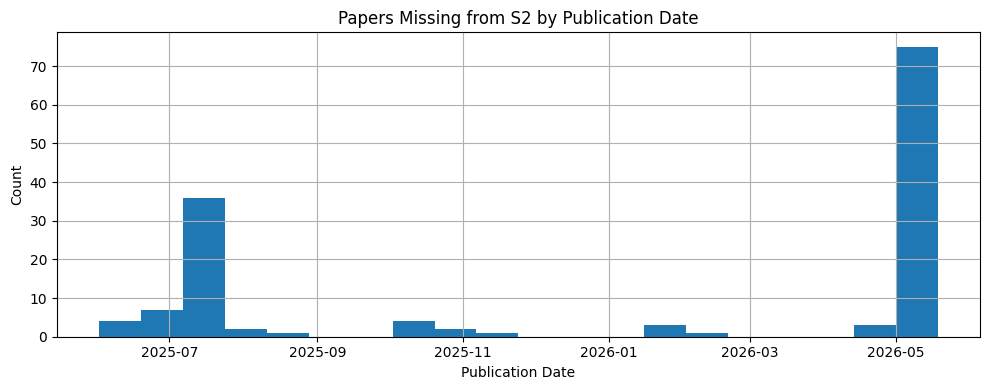

In [119]:
no_scholar = no_scholar.copy()
no_scholar["published"] = pd.to_datetime(no_scholar["published"])

no_scholar["published"].hist(bins=20, figsize=(10, 4))
plt.title("Papers Missing from S2 by Publication Date")
plt.xlabel("Publication Date")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [120]:
r = requests.get("https://api.semanticscholar.org/datasets/v1/release/latest").json()
print(r["release_id"]) 

2026-05-12
